# <font color="#418FDE" size="6.5" uppercase>**Image Datasets and CNNs**</font>

>Last update: 20260412.
    
By the end of this Lecture, you will be able to:
- Organize a civil engineering image dataset into a labeled structure suitable for training and validation. 
- Implement transfer learning by fine-tuning a pre-trained convolutional neural network on a small civil engineering image dataset. 
- Evaluate an image classifier using metrics such as accuracy, precision, and recall with attention to safety-critical classes. 


## **1. Image Data Preparation**

### **1.1. Class Folder Structure**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_A/image_01_01.jpg?v=1775993361" width="250">



>* Separate folders define each image class.
>* Labels must be clear and meaningful.

>* Use consistent, specific, balanced class names.
>* Assign each image to one class.

>* Logical folders improve review and error detection.
>* Structured classes support growth and reliable learning.



TensorFlow version: 2.21.0
Dataset root: /var/folders/nm/7vdrqxq956l44s57z65gy0qm0000gn/T/course_development_datasets/civil_crack_dataset
train cracked images: 24
train intact images: 24
val cracked images: 8
val intact images: 8
Found 48 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Validation accuracy: 1.0
Cracked precision: 1.0
Cracked recall: 1.0


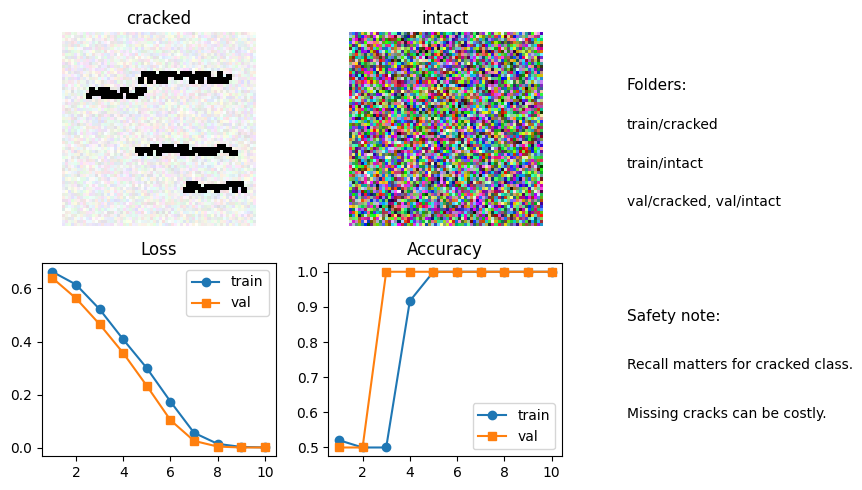

In [39]:
#@title Python Code - Class Folder Structure

# This script shows class folder structure.
# It uses tiny civil image examples.
# It trains a simple CNN model.


# Install packages only if needed.
# !pip install tensorflow scikit-learn

import os, shutil, random, warnings, tempfile
from pathlib import Path
import numpy as np, pandas as pd

import matplotlib.pyplot as plt

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score

tf.get_logger().setLevel('ERROR')

# Set seeds for repeatable results.
random.seed(7)
np.random.seed(7)

tf.random.set_seed(7)

# Use a stable temporary location instead of a relative path.
dataset_root = Path(tempfile.gettempdir()) / 'course_development_datasets'
dataset_root.mkdir(parents=True, exist_ok=True)

base_dir = dataset_root / 'civil_crack_dataset'

# Rebuild a clean folder structure.
if base_dir.exists():
    shutil.rmtree(base_dir)

base_dir.mkdir(parents=True, exist_ok=True)
classes = ['cracked', 'intact']

# Create train and validation folders.
for split_name in ['train', 'val']:
    for class_name in classes:

        folder_path = base_dir / split_name / class_name
        folder_path.mkdir(parents=True, exist_ok=True)

# Make simple synthetic crack images.
img_size = 64
train_count = 24

val_count = 8

# Draw one synthetic image.
def make_image(class_name, size):
    image = np.ones((size, size, 3), dtype=np.uint8) * 190

    noise = np.random.randint(0, 25, (size, size, 3), dtype=np.uint8)
    image = np.clip(image + noise, 0, 255)
    if class_name == 'cracked':

        for _ in range(4):
            x1 = random.randint(5, size - 6)
            y1 = random.randint(5, size - 6)

            length = random.randint(18, 36)
            for step in range(length):
                x2 = min(size - 1, x1 + step)

                y2 = min(size - 1, max(0, y1 + random.randint(-1, 1)))
                image[y2:y2 + 2, x2:x2 + 2] = 30
    return image

# Save images into class folders.
for class_name in classes:
    for i in range(train_count):

        image = make_image(class_name, img_size)
        file_path = base_dir / 'train' / class_name / f'{class_name}_{i}.png'
        tf.keras.utils.save_img(file_path, image)

    for i in range(val_count):
        image = make_image(class_name, img_size)
        file_path = base_dir / 'val' / class_name / f'{class_name}_{i}.png'

        tf.keras.utils.save_img(file_path, image)

# Summarize the folder structure.
summary_rows = []
for split_name in ['train', 'val']:

    for class_name in classes:
        folder_path = base_dir / split_name / class_name
        count = len(os.listdir(folder_path))

        summary_rows.append([split_name, class_name, count])
summary_df = pd.DataFrame(summary_rows, columns=['split', 'class', 'images'])

# Print a short dataset summary.
print('TensorFlow version:', tf.__version__)
print('Dataset root:', str(base_dir))

for row in summary_rows:
    print(row[0], row[1], 'images:', row[2])

# Load datasets from folders.
batch_size = 8
train_ds = tf.keras.utils.image_dataset_from_directory(

    str(base_dir / 'train'),
    image_size=(img_size, img_size),
    batch_size=batch_size,

    shuffle=True,
    seed=7)

val_ds = tf.keras.utils.image_dataset_from_directory(
    str(base_dir / 'val'),
    image_size=(img_size, img_size),

    batch_size=batch_size,
    shuffle=False)

# Cache and prefetch small datasets.
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

class_names = ['cracked', 'intact']

# Build a lightweight LeNet style model.
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1.0 / 255, input_shape=(img_size, img_size, 3)),

    tf.keras.layers.Conv2D(6, 5, activation='relu', padding='same'),
    tf.keras.layers.AveragePooling2D(2),
    tf.keras.layers.Conv2D(16, 5, activation='relu'),

    tf.keras.layers.AveragePooling2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(2, activation='softmax')])

# Compile the classifier.
model.compile(
    optimizer='adam',

    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Train quietly for a few epochs.
history = model.fit(
    train_ds,

    validation_data=val_ds,
    epochs=10,
    verbose=0)

# Collect validation predictions.
true_labels = []
pred_labels = []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    true_labels.extend(labels.numpy().tolist())
    pred_labels.extend(preds.tolist())

# Compute simple evaluation metrics.
acc = accuracy_score(true_labels, pred_labels)
prec = precision_score(true_labels, pred_labels, average=None, zero_division=0)

rec = recall_score(true_labels, pred_labels, average=None, zero_division=0)
print('Validation accuracy:', round(acc, 3))
print('Cracked precision:', round(float(prec[0]), 3))

print('Cracked recall:', round(float(rec[0]), 3))

# Show samples and training curves.
fig, axes = plt.subplots(2, 3, figsize=(9, 5))
for class_index in range(2):

    sample_path = base_dir / 'train' / class_names[class_index]
    sample_file = sorted(os.listdir(sample_path))[0]
    image = tf.keras.utils.load_img(sample_path / sample_file)

    axes[0, class_index].imshow(image)
    axes[0, class_index].set_title(class_names[class_index])
    axes[0, class_index].axis('off')

axes[0, 2].axis('off')
axes[0, 2].text(0.05, 0.7, 'Folders:', fontsize=11)
axes[0, 2].text(0.05, 0.5, 'train/cracked', fontsize=10)

axes[0, 2].text(0.05, 0.3, 'train/intact', fontsize=10)
axes[0, 2].text(0.05, 0.1, 'val/cracked, val/intact', fontsize=10)

# Plot loss and accuracy histories.
epochs = range(1, len(history.history['loss']) + 1)
axes[1, 0].plot(epochs, history.history['loss'], marker='o', label='train')

axes[1, 0].plot(epochs, history.history['val_loss'], marker='s', label='val')
axes[1, 0].set_title('Loss')
axes[1, 0].legend()

axes[1, 1].plot(epochs, history.history['accuracy'], marker='o', label='train')
axes[1, 1].plot(epochs, history.history['val_accuracy'], marker='s', label='val')
axes[1, 1].set_title('Accuracy')

axes[1, 1].legend()
axes[1, 2].axis('off')
axes[1, 2].text(0.05, 0.7, 'Safety note:', fontsize=11)

axes[1, 2].text(0.05, 0.45, 'Recall matters for cracked class.', fontsize=10)
axes[1, 2].text(0.05, 0.2, 'Missing cracks can be costly.', fontsize=10)
plt.tight_layout()

plt.show()

### **1.2. Training Validation Split**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_A/image_01_02.jpg?v=1775993409" width="250">



>* Training learns; validation tests unseen images.
>* Realistic splits prevent misleading memorization.

>* Prevent leakage by grouping related images.
>* Keep validation classes balanced, especially critical ones.

>* Balance training size with representative validation.
>* Split should reflect real inspection variability.



TensorFlow version: 2.21.0
Overall counts: {'corrosion': 300, 'crack': 300, 'intact': 300, 'leakage': 300}
Training counts: {'crack': 223, 'corrosion': 232, 'intact': 229, 'leakage': 216}
Validation counts: {'crack': 79, 'corrosion': 68, 'intact': 75, 'leakage': 78}
Validation accuracy: 0.683
Macro precision: 0.693
Macro recall: 0.685


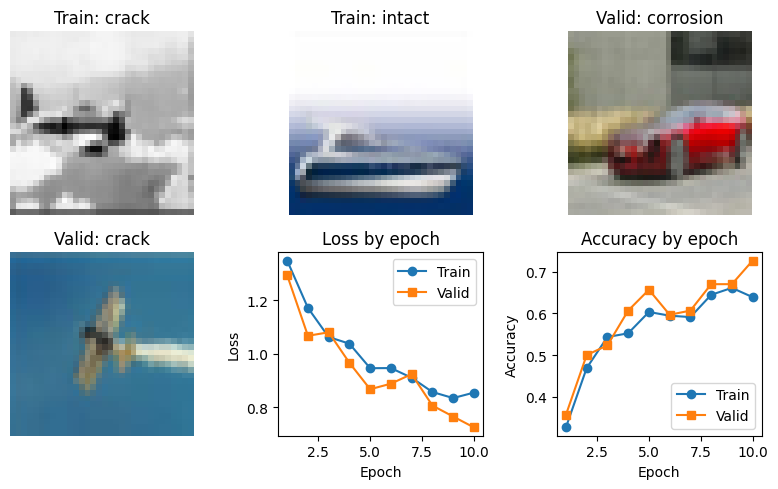

In [23]:
#@title Python Code - Training Validation Split

# Prepare image data for training splits.
# Use a small CNN example here.
# Civil engineering labels are simulated.


# import os, warnings
# !pip install -q tensorflow scikit-learn

import os, warnings, random, math, tempfile
from pathlib import Path
import numpy as np, pandas as pd

import matplotlib.pyplot as plt

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
import tensorflow as tf

tf.get_logger().setLevel('ERROR')
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import accuracy_score

# Set deterministic random seeds.
seed_value = 7
random.seed(seed_value)

np.random.seed(seed_value)

tf.random.set_seed(seed_value)

# Recover to a valid working directory if the current one was removed.
safe_work_dir = Path(tempfile.gettempdir()) / 'course_development_notebook'
safe_work_dir.mkdir(parents=True, exist_ok=True)

try:
    os.getcwd()
except FileNotFoundError:

    os.chdir(safe_work_dir)

print('TensorFlow version:', tf.__version__)

# Load a small CIFAR-10 subset.
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()
class_names = ['crack', 'corrosion', 'intact', 'leakage']

# Keep four classes for demonstration.
selected_ids = [0, 1, 8, 9]
selected_names = {}

selected_names[0] = 'crack'
selected_names[1] = 'corrosion'

selected_names[8] = 'intact'
selected_names[9] = 'leakage'
mask = np.isin(y_train.flatten(), selected_ids)

images = x_train[mask]

labels_raw = y_train.flatten()[mask]
label_map = {0: 0, 1: 1, 8: 2, 9: 3}
labels = np.array([label_map[int(v)] for v in labels_raw])

# Limit dataset size for speed.
max_per_class = 300
small_images = []

small_labels = []

for class_id in range(4):
    class_idx = np.where(labels == class_id)[0][:max_per_class]
    small_images.append(images[class_idx])

    small_labels.append(labels[class_idx])

images = np.concatenate(small_images, axis=0)
labels = np.concatenate(small_labels, axis=0)

# Shuffle the small dataset.
shuffle_idx = np.arange(len(images))
np.random.shuffle(shuffle_idx)

images = images[shuffle_idx]
labels = labels[shuffle_idx]

# Create a labeled dataframe.
label_text = []
for value in labels:

    label_text.append(class_names[int(value)])

df = pd.DataFrame({'label_id': labels, 'label_name': label_text})

# Show overall class counts.
overall_counts = df['label_name'].value_counts().sort_index()
print('Overall counts:', overall_counts.to_dict())

# Build TensorFlow datasets.
image_size = (32, 32)
batch_size = 32

validation_ratio = 0.25

full_ds = tf.data.Dataset.from_tensor_slices((images, labels))
full_ds = full_ds.shuffle(len(images), seed=seed_value)

val_size = int(len(images) * validation_ratio)
train_size = len(images) - val_size
train_ds = full_ds.take(train_size)

val_ds = full_ds.skip(train_size)
train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)

# Normalize images after batching.
def preprocess(image_batch, label_batch):
    image_batch = tf.cast(image_batch, tf.float32) / 255.0

    return image_batch, label_batch

train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
# Count split distributions safely.
train_counts = np.zeros(4, dtype=int)

val_counts = np.zeros(4, dtype=int)

for _, batch_labels in train_ds:
    values = batch_labels.numpy()
    for item in values:

        train_counts[int(item)] += 1

for _, batch_labels in val_ds:
    values = batch_labels.numpy()
    for item in values:

        val_counts[int(item)] += 1

# Print split summaries.
train_dict = {}
val_dict = {}

for i in range(4):
    train_dict[class_names[i]] = int(train_counts[i])
    val_dict[class_names[i]] = int(val_counts[i])

print('Training counts:', train_dict)
print('Validation counts:', val_dict)

# Build a small LeNet style CNN.
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(32, 32, 3)))

model.add(tf.keras.layers.Conv2D(16, 3, activation='relu'))

model.add(tf.keras.layers.MaxPooling2D())
model.add(tf.keras.layers.Conv2D(32, 3, activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(4, activation='softmax'))

# Compile the classifier.
model.compile(
    optimizer='adam',

    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Train quietly for a few epochs.
history = model.fit(
    train_ds,

    validation_data=val_ds,
    epochs=10,
    verbose=0)

# Collect validation predictions.
true_labels = []
pred_labels = []

for image_batch, label_batch in val_ds:
    probs = model.predict(image_batch, verbose=0)
    preds = np.argmax(probs, axis=1)

    true_labels.extend(label_batch.numpy().tolist())
    pred_labels.extend(preds.tolist())

# Compute simple evaluation metrics.
acc = accuracy_score(true_labels, pred_labels)
prec = precision_score(true_labels, pred_labels, average='macro')

rec = recall_score(true_labels, pred_labels, average='macro')

print('Validation accuracy:', round(acc, 3))
print('Macro precision:', round(prec, 3))
print('Macro recall:', round(rec, 3))

# Prepare images for one combined figure.
train_batch = next(iter(train_ds))
val_batch = next(iter(val_ds))

train_images = train_batch[0].numpy()
train_labels = train_batch[1].numpy()

val_images = val_batch[0].numpy()
val_labels = val_batch[1].numpy()
epochs = range(1, len(history.history['loss']) + 1)

# Create one figure with all results.
fig = plt.figure(figsize=(8, 5))

ax1 = plt.subplot(2, 3, 1)
ax1.imshow(train_images[0])
ax1.set_title('Train: ' + class_names[int(train_labels[0])])

ax1.axis('off')
ax2 = plt.subplot(2, 3, 2)
ax2.imshow(train_images[1])

ax2.set_title('Train: ' + class_names[int(train_labels[1])])

ax2.axis('off')
ax3 = plt.subplot(2, 3, 3)
ax3.imshow(val_images[0])

ax3.set_title('Valid: ' + class_names[int(val_labels[0])])

ax3.axis('off')
ax4 = plt.subplot(2, 3, 4)
ax4.imshow(val_images[1])

ax4.set_title('Valid: ' + class_names[int(val_labels[1])])

ax4.axis('off')
ax5 = plt.subplot(2, 3, 5)
ax5.plot(epochs, history.history['loss'], marker='o')

ax5.plot(epochs, history.history['val_loss'], marker='s')

ax5.set_title('Loss by epoch')
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Loss')

ax5.legend(['Train', 'Valid'])

ax6 = plt.subplot(2, 3, 6)
ax6.plot(epochs, history.history['accuracy'], marker='o')
ax6.plot(epochs, history.history['val_accuracy'], marker='s')

ax6.set_title('Accuracy by epoch')
ax6.set_xlabel('Epoch')
ax6.set_ylabel('Accuracy')

ax6.legend(['Train', 'Valid'])

plt.tight_layout()
plt.show()

### **1.3. Augmentation Essentials**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_A/image_01_03.jpg?v=1775993450" width="250">



>* Augmentation creates realistic image variations.
>* It improves robustness to changing conditions.

>* Use realistic changes that preserve class meaning.
>* Avoid distortions that remove important defect cues.

>* Augment training data, keep validation realistic.
>* Balance classes carefully; preserve honest dataset limits.



TensorFlow version: 2.21.0
Baseline best val accuracy: 0.568
Augmented best val accuracy: 0.516
Final test accuracy: 0.506


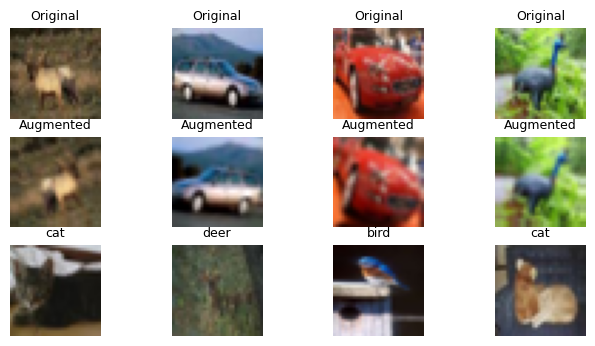

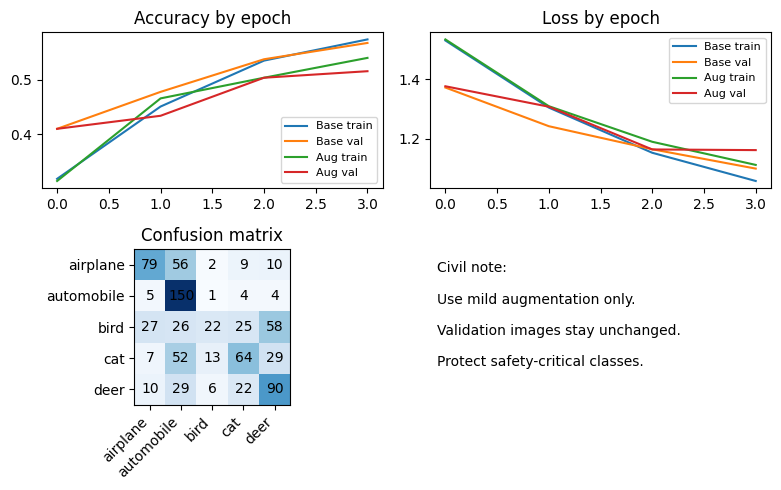

In [15]:
#@title Python Code - Augmentation Essentials

# Augmentation helps models learn realistic inspection variation.
# This example uses a tiny image subset.
# We compare training with and without augmentation.

# pip install scikit-learn==1.8.0

import os, warnings, random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

random.seed(7); np.random.seed(7); tf.random.set_seed(7)

# Report framework version briefly.
print('TensorFlow version:', tf.__version__)

# Load a small CIFAR-10 subset.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer']

# Keep five classes for speed.
train_mask = np.isin(y_train.flatten(), [0, 1, 2, 3, 4])
test_mask = np.isin(y_test.flatten(), [0, 1, 2, 3, 4])

x_train = x_train[train_mask][:2500].astype('float32') / 255.0
y_train = y_train[train_mask][:2500].flatten()

x_test = x_test[test_mask][:800].astype('float32') / 255.0
y_test = y_test[test_mask][:800].flatten()

# Create validation data safely.
val_size = 500
x_val = x_train[-val_size:]

y_val = y_train[-val_size:]
x_train_small = x_train[:-val_size]
y_train_small = y_train[:-val_size]

# Build augmentation layers.
augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),

    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.15)])

# Show original and augmented images.
fig, axes = plt.subplots(3, 4, figsize=(8, 4))
for i in range(4):

    axes[0, i].imshow(x_train_small[i])
    axes[0, i].set_title('Original', fontsize=9)
    axes[0, i].axis('off')

for i in range(4):
    aug_img = augmenter(x_train_small[i:i+1], training=True)[0].numpy()
    axes[1, i].imshow(np.clip(aug_img, 0, 1))

    axes[1, i].set_title('Augmented', fontsize=9)
    axes[1, i].axis('off')

for i in range(4):
    axes[2, i].imshow(x_train_small[i + 4])
    axes[2, i].set_title(class_names[y_train_small[i + 4]], fontsize=9)

    axes[2, i].axis('off')

# Build a small CNN.
def make_model(use_augmentation):
    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Input(shape=(32, 32, 3)))
    if use_augmentation:
        model.add(augmenter)

    model.add(tf.keras.layers.Conv2D(16, 3, activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D())
    model.add(tf.keras.layers.Conv2D(32, 3, activation='relu'))

    model.add(tf.keras.layers.MaxPooling2D())
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(64, activation='relu'))

    model.add(tf.keras.layers.Dense(5, activation='softmax'))
    model.compile(
        optimizer='adam',

        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])
    return model

# Train baseline model quietly.
baseline_model = make_model(False)
history_base = baseline_model.fit(

    x_train_small, y_train_small,
    validation_data=(x_val, y_val),
    epochs=4, batch_size=64, verbose=0)

# Train augmented model quietly.
aug_model = make_model(True)
history_aug = aug_model.fit(

    x_train_small, y_train_small,
    validation_data=(x_val, y_val),
    epochs=4, batch_size=64, verbose=0)

# Evaluate final augmented model.
test_loss, test_acc = aug_model.evaluate(x_test, y_test, verbose=0)
y_prob = aug_model.predict(x_test, verbose=0)

y_pred = np.argmax(y_prob, axis=1)

# Build confusion matrix manually.
cm = tf.math.confusion_matrix(y_test, y_pred, num_classes=5).numpy()

# Plot learning curves and confusion matrix.
fig2, axes2 = plt.subplots(2, 2, figsize=(8, 5))
axes2[0, 0].plot(history_base.history['accuracy'], label='Base train')

axes2[0, 0].plot(history_base.history['val_accuracy'], label='Base val')
axes2[0, 0].plot(history_aug.history['accuracy'], label='Aug train')
axes2[0, 0].plot(history_aug.history['val_accuracy'], label='Aug val')

axes2[0, 0].set_title('Accuracy by epoch')
axes2[0, 0].legend(fontsize=8)

axes2[0, 1].plot(history_base.history['loss'], label='Base train')
axes2[0, 1].plot(history_base.history['val_loss'], label='Base val')
axes2[0, 1].plot(history_aug.history['loss'], label='Aug train')

axes2[0, 1].plot(history_aug.history['val_loss'], label='Aug val')
axes2[0, 1].set_title('Loss by epoch')
axes2[0, 1].legend(fontsize=8)

axes2[1, 0].imshow(cm, cmap='Blues')
axes2[1, 0].set_title('Confusion matrix')
axes2[1, 0].set_xticks(range(5))

axes2[1, 0].set_yticks(range(5))
axes2[1, 0].set_xticklabels(class_names, rotation=45, ha='right')
axes2[1, 0].set_yticklabels(class_names)

for i in range(5):
    for j in range(5):
        axes2[1, 0].text(j, i, str(cm[i, j]), ha='center', va='center')

axes2[1, 1].axis('off')
axes2[1, 1].text(0.02, 0.85, 'Civil note:')
axes2[1, 1].text(0.02, 0.65, 'Use mild augmentation only.')

axes2[1, 1].text(0.02, 0.45, 'Validation images stay unchanged.')
axes2[1, 1].text(0.02, 0.25, 'Protect safety-critical classes.')

# Print short summary lines.
base_best = max(history_base.history['val_accuracy'])
aug_best = max(history_aug.history['val_accuracy'])

print('Baseline best val accuracy:', round(float(base_best), 3))
print('Augmented best val accuracy:', round(float(aug_best), 3))
print('Final test accuracy:', round(float(test_acc), 3))

plt.tight_layout()
plt.show()

## **2. Transfer Learning Fine Tuning**

### **2.1. Pretrained CNN Loading**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_A/image_02_01.jpg?v=1775993498" width="250">



>* Pretrained CNNs bring reusable visual features.
>* They learn faster from small datasets.

>* Choose architecture for speed, accuracy, resources.
>* Adapt input format; reuse general visual features.

>* Pretrained CNNs provide reusable visual features.
>* They need tuning for engineering tasks.



TensorFlow version: 2.21.0
Running on: CPU
Classes used: ['airplane', 'automobile', 'bird', 'cat', 'deer']
Train, val, test: 2000 500 500


Transfer model summary: Model: "sequential_43"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 5)              │         6,405 │
└────────────────────────────

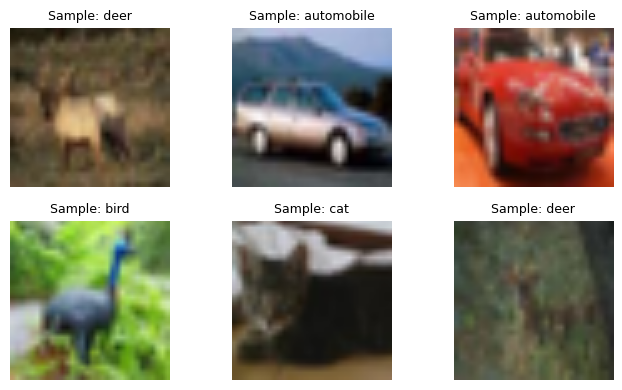

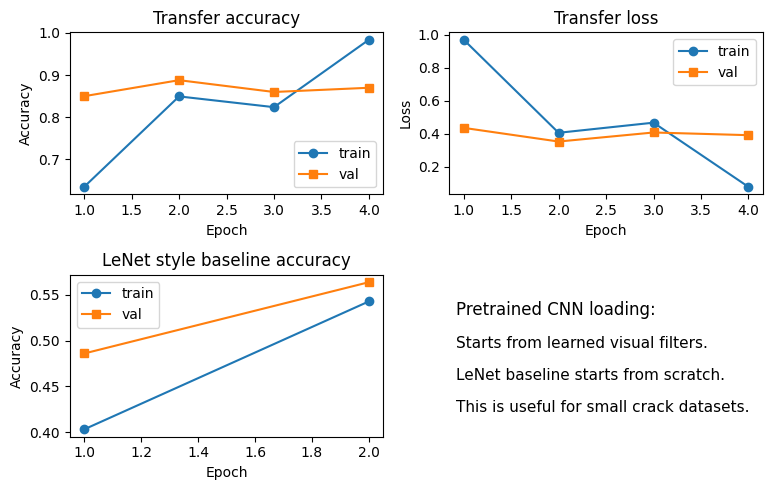

In [24]:
#@title Python Code - Pretrained CNN Loading

# Load a pretrained CNN for crack images.
# Transfer learning starts from learned visual features.
# This example uses a tiny CIFAR subset.

import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
tf.random.set_seed(7)

print('TensorFlow version:', tf.__version__)

# Check whether GPU is available.
gpu_name = 'GPU' if tf.config.list_physical_devices('GPU') else 'CPU'
print('Running on:', gpu_name)

# Load CIFAR-10 as a substitute dataset.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer']

# Keep only five classes for speed.
train_mask = y_train.flatten() < 5
test_mask = y_test.flatten() < 5

x_train = x_train[train_mask]
y_train = y_train[train_mask].flatten()

x_test = x_test[test_mask]
y_test = y_test[test_mask].flatten()
print('Classes used:', class_names)

# Use a small subset for quick teaching.
train_count = 2000
val_count = 500

test_count = 500
x_train = x_train[:train_count + val_count]

y_train = y_train[:train_count + val_count]
x_test = x_test[:test_count]
y_test = y_test[:test_count]

# Resize images for MobileNetV2 input.
image_size = 96
x_train = tf.image.resize(x_train, (image_size, image_size)).numpy()

x_test = tf.image.resize(x_test, (image_size, image_size)).numpy()

# Split training and validation sets.
x_val = x_train[train_count:train_count + val_count]
y_val = y_train[train_count:train_count + val_count]

x_train = x_train[:train_count]
y_train = y_train[:train_count]

# Prepare arrays for two model styles.
x_train_float = x_train.astype('float32')
x_val_float = x_val.astype('float32')

x_test_float = x_test.astype('float32')

# Preprocess for the pretrained backbone.
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input
x_train_pre = preprocess(x_train_float.copy())

x_val_pre = preprocess(x_val_float.copy())

x_test_pre = preprocess(x_test_float.copy())
num_classes = len(class_names)
print('Train, val, test:', x_train_pre.shape[0], x_val_pre.shape[0], x_test_pre.shape[0])

# Show sample images before training.
fig, axes = plt.subplots(2, 3, figsize=(7, 4))
for i in range(3):

    axes[0, i].imshow(x_train_float[i].astype('uint8'))
    axes[0, i].set_title('Sample: ' + class_names[int(y_train[i])], fontsize=9)
    axes[0, i].axis('off')

for i in range(3):
    axes[1, i].imshow(x_train_float[i + 3].astype('uint8'))

    axes[1, i].set_title('Sample: ' + class_names[int(y_train[i + 3])], fontsize=9)

    axes[1, i].axis('off')
plt.tight_layout()

# Build a simple LeNet-style baseline.
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(image_size, image_size, 3)),

    tf.keras.layers.Rescaling(1.0 / 255.0),
    tf.keras.layers.Conv2D(16, 3, activation='relu'),

    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')])

# Compile the baseline model.
baseline_model.compile(
    optimizer='adam',

    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Train the baseline briefly.
baseline_history = baseline_model.fit(
    x_train_float, y_train,

    validation_data=(x_val_float, y_val),
    epochs=2, verbose=0)

# Load a pretrained MobileNetV2 backbone.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(image_size, image_size, 3),

    include_top=False,
    weights='imagenet')

# Freeze most learned visual filters first.
base_model.trainable = False
transfer_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(image_size, image_size, 3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes, activation='softmax')])

# Compile the transfer model.
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Train only the new classifier head.
head_history = transfer_model.fit(
    x_train_pre, y_train,

    validation_data=(x_val_pre, y_val),
    epochs=2, verbose=0)

# Unfreeze a few deeper layers for fine tuning.
base_model.trainable = True
for layer in base_model.layers[:-20]:

    layer.trainable = False

# Recompile with a smaller learning rate.
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),

    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Fine tune the pretrained model briefly.
fine_history = transfer_model.fit(
    x_train_pre, y_train,

    validation_data=(x_val_pre, y_val),
    epochs=2, verbose=0)

# Summarize the transfer model briefly.
summary_lines = []
transfer_model.summary(print_fn=summary_lines.append)

print('Transfer model summary:', summary_lines[0])

# Evaluate the fine tuned model.
probabilities = transfer_model.predict(x_test_pre, verbose=0)
predictions = np.argmax(probabilities, axis=1)

acc = accuracy_score(y_test, predictions)
prec = precision_score(y_test, predictions, average='macro', zero_division=0)

rec = recall_score(y_test, predictions, average='macro', zero_division=0)
results_df = pd.DataFrame({'metric': ['accuracy', 'precision', 'recall'], 'value': [acc, prec, rec]})
print(results_df.round(3).to_string(index=False))

# Compare baseline and transfer learning.
base_val = baseline_history.history['val_accuracy'][-1]
head_val = head_history.history['val_accuracy'][-1]

fine_val = fine_history.history['val_accuracy'][-1]
print('Baseline val accuracy:', round(float(base_val), 3))

print('Transfer head accuracy:', round(float(head_val), 3))
print('Fine tuned accuracy:', round(float(fine_val), 3))

# Combine histories for one teaching plot.
train_acc = head_history.history['accuracy'] + fine_history.history['accuracy']
val_acc = head_history.history['val_accuracy'] + fine_history.history['val_accuracy']

train_loss = head_history.history['loss'] + fine_history.history['loss']

val_loss = head_history.history['val_loss'] + fine_history.history['val_loss']
epochs = np.arange(1, len(train_acc) + 1)

# Plot learning curves in one figure.
fig, axes = plt.subplots(2, 2, figsize=(8, 5))
axes[0, 0].plot(epochs, train_acc, marker='o', label='train')

axes[0, 0].plot(epochs, val_acc, marker='s', label='val')
axes[0, 0].set_title('Transfer accuracy')

axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

axes[0, 1].plot(epochs, train_loss, marker='o', label='train')

axes[0, 1].plot(epochs, val_loss, marker='s', label='val')
axes[0, 1].set_title('Transfer loss')
axes[0, 1].set_xlabel('Epoch')

axes[0, 1].set_ylabel('Loss')

axes[0, 1].legend()
base_epochs = np.arange(1, len(baseline_history.history['accuracy']) + 1)
axes[1, 0].plot(base_epochs, baseline_history.history['accuracy'], marker='o', label='train')

axes[1, 0].plot(base_epochs, baseline_history.history['val_accuracy'], marker='s', label='val')

axes[1, 0].set_title('LeNet style baseline accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')

axes[1, 0].legend()
axes[1, 1].axis('off')

axes[1, 1].text(0.02, 0.75, 'Pretrained CNN loading:', fontsize=12)
axes[1, 1].text(0.02, 0.55, 'Starts from learned visual filters.', fontsize=11)
axes[1, 1].text(0.02, 0.35, 'LeNet baseline starts from scratch.', fontsize=11)

axes[1, 1].text(0.02, 0.15, 'This is useful for small crack datasets.', fontsize=11)

plt.tight_layout()
plt.show()

### **2.2. Freezing Base Layers**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_A/image_02_02.jpg?v=1775993550" width="250">



>* Freeze early layers to keep general features.
>* This reduces overfitting on small datasets.

>* Freezing layers helps small, imbalanced datasets generalize.
>* It reduces overfitting and speeds training.

>* Freeze layers based on image similarity, data.
>* Start frozen; unfreeze deeper layers if needed.



TensorFlow version: 2.21.0
Training device: CPU
Train shape: (2500, 32, 32, 3)
Validation shape: (500, 32, 32, 3)
Test shape: (500, 32, 32, 3)
Trainable parameters: 6405
Frozen parameters: 2257984
Test accuracy: 0.868
Macro precision: 0.866
Macro recall: 0.868


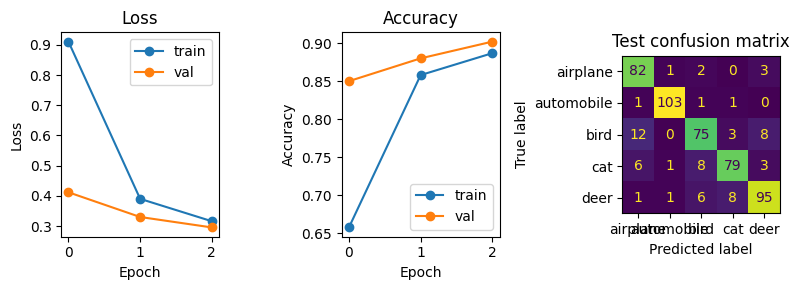

In [19]:
#@title Python Code - Freezing Base Layers

# Transfer learning keeps useful visual features.
# This example freezes pretrained base layers.
# We train only a small classifier.

import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np, matplotlib.pyplot as plt

import pandas as pd
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.metrics import ConfusionMatrixDisplay

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Show the TensorFlow version.
print('TensorFlow version:', tf.__version__)

# Detect available training hardware.
device_name = 'GPU' if tf.config.list_physical_devices('GPU') else 'CPU'
print('Training device:', device_name)

# Load a small CIFAR-10 subset.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer']

# Keep five classes for speed.
keep_classes = [0, 1, 2, 3, 4]
train_mask = np.isin(y_train.flatten(), keep_classes)

test_mask = np.isin(y_test.flatten(), keep_classes)

# Filter the selected classes.
x_train = x_train[train_mask]
y_train = y_train[train_mask].flatten()

x_test = x_test[test_mask]
y_test = y_test[test_mask].flatten()

# Remap labels to zero-based values.
label_map = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
y_train_small = np.array([label_map[int(v)] for v in y_train])

y_test_small = np.array([label_map[int(v)] for v in y_test])

# Use small subsets for runtime.
train_count = 2500
val_count = 500

test_count = 500

# Slice deterministic subsets.
x_train_small = x_train[:train_count]
y_train_small = y_train_small[:train_count]

x_val_small = x_test[:val_count]
y_val_small = y_test_small[:val_count]
x_test_small = x_test[val_count:val_count + test_count]

y_test_small = y_test_small[val_count:val_count + test_count]

# Check basic dataset shapes.
print('Train shape:', x_train_small.shape)
print('Validation shape:', x_val_small.shape)

print('Test shape:', x_test_small.shape)

# Resize images for MobileNetV2.
img_size = (96, 96)
num_classes = len(class_names)

batch_size = 32

# Build TensorFlow datasets.
train_ds = tf.data.Dataset.from_tensor_slices((x_train_small, y_train_small))
val_ds = tf.data.Dataset.from_tensor_slices((x_val_small, y_val_small))

test_ds = tf.data.Dataset.from_tensor_slices((x_test_small, y_test_small))

# Define a simple preprocessing step.
def preprocess(image, label):
    image = tf.image.resize(image, img_size)

    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

# Prepare efficient input pipelines.
train_ds = train_ds.map(preprocess).shuffle(500, seed=7).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Load a lightweight pretrained base.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),

    include_top=False,
    weights='imagenet')

# Freeze all base layers.
base_model.trainable = False

# Build the classifier head.
inputs = tf.keras.Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

# Create the full model.
model = tf.keras.Model(inputs, outputs)
model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Count frozen and trainable weights.
trainable_count = np.sum([np.prod(v.shape) for v in model.trainable_weights])
frozen_count = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print('Trainable parameters:', int(trainable_count))
print('Frozen parameters:', int(frozen_count))

# Train only the classifier head.
history = model.fit(
    train_ds,

    validation_data=val_ds,
    epochs=3,
    verbose=0)

# Evaluate on the test subset.
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print('Test accuracy:', round(float(test_acc), 3))

# Predict class probabilities.
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Compute safety-style metrics.
report = classification_report(
    y_test_small,

    y_pred,
    target_names=class_names,
    output_dict=True,

    zero_division=0)
report_df = pd.DataFrame(report).T
print('Macro precision:', round(float(report_df.loc['macro avg', 'precision']), 3))

print('Macro recall:', round(float(report_df.loc['macro avg', 'recall']), 3))

# Build the confusion matrix.
cm = confusion_matrix(y_test_small, y_pred)

# Create one figure with all results.
fig, axes = plt.subplots(1, 3, figsize=(8, 3))

# Plot training and validation loss.
axes[0].plot(history.history['loss'], marker='o', label='train')
axes[0].plot(history.history['val_loss'], marker='o', label='val')

axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[0].legend()

# Plot training and validation accuracy.
axes[1].plot(history.history['accuracy'], marker='o', label='train')
axes[1].plot(history.history['val_accuracy'], marker='o', label='val')

axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

axes[1].legend()

# Plot the confusion matrix.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[2], colorbar=False)

axes[2].set_title('Test confusion matrix')
plt.tight_layout()
plt.show()

### **2.3. Refining Final Layers**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_A/image_02_03.jpg?v=1775993594" width="250">



>* Final layers adapt CNNs to defects.
>* They learn subtle engineering visual differences.

>* Replace output layers for civil classes
>* Train carefully despite varied, limited images

>* Balance refinement to avoid underfitting and overfitting.
>* Reliable defect detection matters in safety decisions.



TensorFlow version: 2.21.0
Running on: CPU
Train, val, test: 2500 500 500
Test accuracy: 0.912
     Class  Precision  Recall
  airplane      0.933   0.898
automobile      0.950   1.000
      bird      0.912   0.830
       cat      0.921   0.886
      deer      0.846   0.957


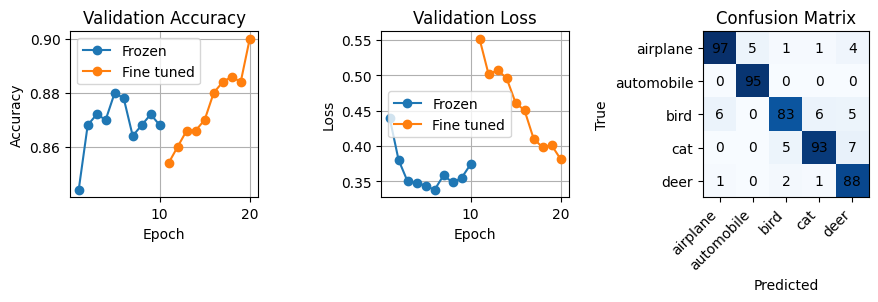

In [31]:
#@title Python Code - Refining Final Layers

# Transfer learning refines task specific image decisions.
# We fine tune final layers carefully.
# Civil images need reliable defect recognition.

# TensorFlow usually comes preinstalled in Colab.

import os, warnings, random, math
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Show the framework version briefly.
print('TensorFlow version:', tf.__version__)

# Detect available hardware safely.
gpu_name = 'GPU' if tf.config.list_physical_devices('GPU') else 'CPU'
print('Running on:', gpu_name)

# Load a small CIFAR-10 subset.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.reshape(-1)

y_test = y_test.reshape(-1)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer']

# Keep only five classes.
train_mask = y_train < 5
test_mask = y_test < 5

x_train = x_train[train_mask]
y_train = y_train[train_mask]
x_test = x_test[test_mask]

y_test = y_test[test_mask]

# Use a small fast subset.
train_count = 2500
val_count = 500

test_count = 500
x_train = x_train[:train_count + val_count]
y_train = y_train[:train_count + val_count]

x_test = x_test[:test_count]
y_test = y_test[:test_count]

# Split training and validation sets.
x_val = x_train[train_count:train_count + val_count]
y_val = y_train[train_count:train_count + val_count]

x_train = x_train[:train_count]
y_train = y_train[:train_count]

# Check basic dataset shapes.
print('Train, val, test:', x_train.shape[0], x_val.shape[0], x_test.shape[0])

# Resize images for MobileNetV2.
img_size = 96
batch_size = 32

num_classes = len(class_names)

# Build TensorFlow datasets.
def prepare_dataset(images, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))

    if training:
        ds = ds.shuffle(1000, seed=7)
    ds = ds.batch(batch_size)

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# Preprocess each image batch.
def preprocess_batch(images, labels):
    images = tf.image.resize(images, (img_size, img_size))

    images = tf.cast(images, tf.float32)
    images = tf.keras.applications.mobilenet_v2.preprocess_input(images)
    return images, labels

# Create mapped datasets.
train_ds = prepare_dataset(x_train, y_train, True)
val_ds = prepare_dataset(x_val, y_val, False)

test_ds = prepare_dataset(x_test, y_test, False)

# Apply preprocessing maps.
train_ds = train_ds.map(preprocess_batch, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess_batch, num_parallel_calls=tf.data.AUTOTUNE)

test_ds = test_ds.map(preprocess_batch, num_parallel_calls=tf.data.AUTOTUNE)

# Build a transfer learning model.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_size, img_size, 3),

    include_top=False,
    weights='imagenet')

# Freeze all pretrained layers first.
base_model.trainable = False
inputs = tf.keras.Input(shape=(img_size, img_size, 3))

x = base_model(inputs, training=False)

# Add a small custom classifier.
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.20)(x)

outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

# Compile the frozen model.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Train only the new classifier.
history_frozen = model.fit(
    train_ds,

    validation_data=val_ds,
    epochs=10,
    verbose=0)

# Unfreeze selected top layers.
base_model.trainable = True
for layer in base_model.layers[:-20]:

    layer.trainable = False

# Recompile with a smaller rate.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),

    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Fine tune the final layers.
history_tuned = model.fit(
    train_ds,

    validation_data=val_ds,
    epochs=10,
    verbose=0)

# Predict test labels silently.
probabilities = model.predict(test_ds, verbose=0)
y_pred = np.argmax(probabilities, axis=1)

# Compute safety style metrics.
report = classification_report(
    y_test,

    y_pred,
    target_names=class_names,
    output_dict=True,

    zero_division=0)

# Build a compact metrics table.
rows = []
for name in class_names:

    rows.append([
        name,
        round(report[name]['precision'], 3),

        round(report[name]['recall'], 3)])
metrics_df = pd.DataFrame(rows, columns=['Class', 'Precision', 'Recall'])

# Print concise evaluation results.
print('Test accuracy:', round(report['accuracy'], 3))
print(metrics_df.to_string(index=False))

# Create a confusion matrix.
cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))

# Combine training histories for plotting.
frozen_acc = history_frozen.history['val_accuracy']
tuned_acc = history_tuned.history['val_accuracy']

frozen_loss = history_frozen.history['val_loss']
tuned_loss = history_tuned.history['val_loss']

# Make one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

# Plot validation accuracy comparison.
axes[0].plot(range(1, len(frozen_acc) + 1), frozen_acc, marker='o', label='Frozen')
axes[0].plot(range(len(frozen_acc) + 1, len(frozen_acc) + len(tuned_acc) + 1), tuned_acc, marker='o', label='Fine tuned')

axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')

axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot validation loss comparison.
axes[1].plot(range(1, len(frozen_loss) + 1), frozen_loss, marker='o', label='Frozen')
axes[1].plot(range(len(frozen_loss) + 1, len(frozen_loss) + len(tuned_loss) + 1), tuned_loss, marker='o', label='Fine tuned')

axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')

axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Plot the confusion matrix.
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_title('Confusion Matrix')

axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

axes[2].set_xticks(np.arange(num_classes))
axes[2].set_yticks(np.arange(num_classes))
axes[2].set_xticklabels(class_names, rotation=45, ha='right')

axes[2].set_yticklabels(class_names)

# Add matrix cell values.
for i in range(num_classes):
    for j in range(num_classes):

        axes[2].text(j, i, str(cm[i, j]), ha='center', va='center')

# Finish the single required plot.
plt.tight_layout()
plt.show()

## **3. Classifier Evaluation Metrics**

### **3.1. Reading Confusion Matrices**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_A/image_03_01.jpg?v=1775993640" width="250">



>* Confusion matrices show correct and wrong classes.
>* Error types matter for safety decisions.

>* Check true and predicted class perspectives.
>* Reveals missed defects, false alarms, bias.

>* Prioritize dangerous misclassifications over overall accuracy.
>* Use errors to improve data and thresholds.



TensorFlow version: 2.21.0
Using device: CPU
Test accuracy: 0.272
Macro precision: 0.303
Macro recall: 0.267
Safety recall for truck: 0.688
Truck images often predicted as: dog


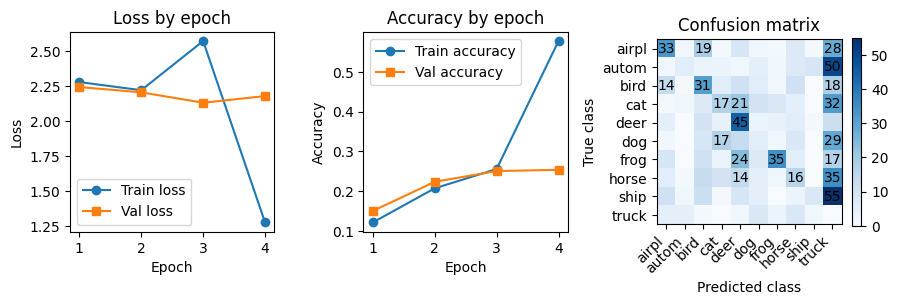

In [34]:
#@title Python Code - Reading Confusion Matrices

# Read confusion matrices for crack classification.
# This example uses a tiny CIFAR subset.
# Safety classes need careful error review.

# Import quiet libraries and set seeds.
import os, warnings, random
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Import TensorFlow and sklearn metrics.
import tensorflow as tf
from sklearn.metrics import confusion_matrix, precision_score

from sklearn.metrics import recall_score, accuracy_score

# Silence TensorFlow messages.
tf.get_logger().setLevel("ERROR")
np.random.seed(7)

random.seed(7)
tf.random.set_seed(7)

# Show framework version briefly.
print("TensorFlow version:", tf.__version__)
print("Using device:", "GPU" if tf.config.list_physical_devices("GPU") else "CPU")

# Load CIFAR-10 demonstration data.
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.cifar10.load_data()
class_names = ["airplane", "automobile", "bird", "cat", "deer",

               "dog", "frog", "horse", "ship", "truck"]

# Keep a small fast subset.
train_n = 4000
val_n = 1000

test_n = 1000
x_train = train_x[:train_n].astype("float32") / 255.0

# Prepare labels and splits.
y_train = train_y[:train_n].reshape(-1)
x_val = train_x[train_n:train_n + val_n].astype("float32") / 255.0

y_val = train_y[train_n:train_n + val_n].reshape(-1)
x_test = test_x[:test_n].astype("float32") / 255.0

# Finish test labels safely.
y_test = test_y[:test_n].reshape(-1)
assert x_train.shape[0] == y_train.shape[0]

assert x_val.shape[0] == y_val.shape[0]
assert x_test.shape[0] == y_test.shape[0]

# Build a lightweight transfer model.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(32, 32, 3), include_top=False,

    weights="imagenet")

# Freeze most layers first.
base_model.trainable = False
inputs = tf.keras.Input(shape=(32, 32, 3))

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base_model(x, training=False)

# Add simple classifier layers.
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(10, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

# Compile the first training stage.
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),

    loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train quietly for a few epochs.
history1 = model.fit(
    x_train, y_train, validation_data=(x_val, y_val),

    epochs=2, batch_size=64, verbose=0)

# Unfreeze a few top layers.
base_model.trainable = True
for layer in base_model.layers[:-20]:

    layer.trainable = False

# Compile the fine tuning stage.
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),

    loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Continue training quietly.
history2 = model.fit(
    x_train, y_train, validation_data=(x_val, y_val),

    epochs=2, batch_size=64, verbose=0)

# Combine training histories simply.
train_loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]

train_acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]

# Predict test classes quietly.
probabilities = model.predict(x_test, verbose=0)
y_pred = np.argmax(probabilities, axis=1)

cm = confusion_matrix(y_test, y_pred, labels=np.arange(10))

# Compute evaluation metrics.
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro", zero_division=0)

rec = recall_score(y_test, y_pred, average="macro", zero_division=0)

# Treat trucks as safety critical.
safety_class = 9
safety_name = class_names[safety_class]

safety_recall = recall_score(
    y_test == safety_class, y_pred == safety_class,
    zero_division=0)

# Summarize key results briefly.
print("Test accuracy:", round(acc, 3))
print("Macro precision:", round(prec, 3))

print("Macro recall:", round(rec, 3))
print("Safety recall for", safety_name + ":", round(safety_recall, 3))

# Find common truck confusions.
truck_row = cm[safety_class]
truck_row[safety_class] = 0

most_confused = int(np.argmax(truck_row))
print("Truck images often predicted as:", class_names[most_confused])

# Create one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
epochs = np.arange(1, len(train_loss) + 1)

axes[0].plot(epochs, train_loss, marker="o", label="Train loss")
axes[0].plot(epochs, val_loss, marker="s", label="Val loss")

# Label the loss panel.
axes[0].set_title("Loss by epoch")
axes[0].set_xlabel("Epoch")

axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot the accuracy panel.
axes[1].plot(epochs, train_acc, marker="o", label="Train accuracy")
axes[1].plot(epochs, val_acc, marker="s", label="Val accuracy")

axes[1].set_title("Accuracy by epoch")
axes[1].set_xlabel("Epoch")

# Finish the accuracy panel.
axes[1].set_ylabel("Accuracy")
axes[1].legend()

image = axes[2].imshow(cm, cmap="Blues")
axes[2].set_title("Confusion matrix")

# Label confusion matrix axes.
axes[2].set_xlabel("Predicted class")
axes[2].set_ylabel("True class")

axes[2].set_xticks(np.arange(10))
axes[2].set_yticks(np.arange(10))

# Use short class labels.
short_names = [name[:5] for name in class_names]
axes[2].set_xticklabels(short_names, rotation=45, ha="right")

axes[2].set_yticklabels(short_names)
fig.colorbar(image, ax=axes[2], fraction=0.046)

# Add a few readable counts.
for i in range(10):
    for j in range(10):

        if cm[i, j] >= np.max(cm) * 0.25:
            axes[2].text(j, i, str(cm[i, j]), ha="center", va="center")

# Tighten layout and show figure.
plt.tight_layout()
plt.show()

### **3.2. Precision Recall Tradeoffs**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_A/image_03_02.jpg?v=1775993684" width="250">



>* Precision trusts alerts; recall finds defects.
>* Higher precision can miss critical damage.

>* Threshold choice shifts precision and recall.
>* Set thresholds by inspection costs and goals.

>* Prioritize recall when missed defects are dangerous.
>* Balance precision with workload, trust, and goals.



TensorFlow version: 2.21.0
Positive class: crack-like images needing review
Threshold 0.50 -> acc 0.865, prec 0.940, rec 0.780, f1 0.852
Threshold 0.30 -> acc 0.900, prec 0.926, rec 0.870, f1 0.897
False negatives at 0.50: 44
False negatives at 0.30: 26
Lower threshold often raises recall, reducing missed defects.
In safety-critical inspections, false negatives can hide damage.


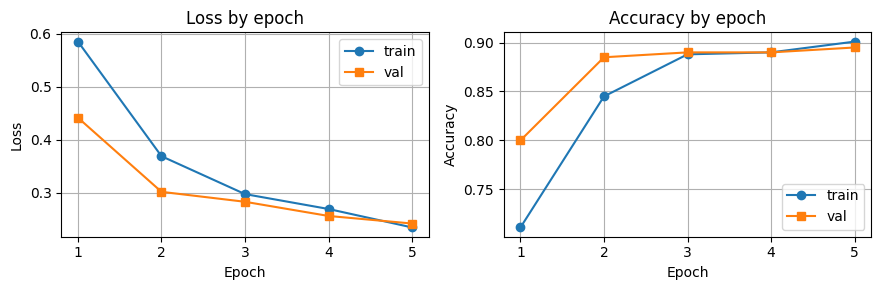

In [35]:
#@title Python Code - Precision Recall Tradeoffs

# Precision and recall guide safer inspections.
# Small CNN example uses binary images.
# False negatives matter in safety tasks.

# Required installs are usually unnecessary.
# !pip install tensorflow scikit-learn matplotlib pandas

# Import quiet libraries for clean output.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np

# Import plotting and learning tools.
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

# Import evaluation metrics only.
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix

from sklearn.metrics import accuracy_score

# Set seeds for repeatable results.
random.seed(7)
np.random.seed(7)

tf.random.set_seed(7)
print('TensorFlow version:', tf.__version__)

# Load CIFAR-10 as a substitute dataset.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.reshape(-1)

y_test = y_test.reshape(-1)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer']

# Keep only two classes.
crack_like_class = 3
intact_like_class = 1

train_mask = np.logical_or(y_train == crack_like_class, y_train == intact_like_class)
test_mask = np.logical_or(y_test == crack_like_class, y_test == intact_like_class)

# Build small binary subsets.
x_train = x_train[train_mask]
y_train = y_train[train_mask]

x_test = x_test[test_mask]
y_test = y_test[test_mask]
train_limit = 1200

test_limit = 400

# Slice small fast subsets.
x_train = x_train[:train_limit]
y_train = y_train[:train_limit]

x_test = x_test[:test_limit]
y_test = y_test[:test_limit]
y_train = (y_train == crack_like_class).astype('float32')

y_test = (y_test == crack_like_class).astype('float32')

# Normalize image values safely.
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

if x_train.shape[0] == 0:
    raise ValueError('Training subset is empty.')

# Create validation split manually.
val_size = 200
x_val = x_train[-val_size:]

y_val = y_train[-val_size:]
x_train_small = x_train[:-val_size]
y_train_small = y_train[:-val_size]

# Build a lightweight CNN.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')])
model.compile(
    optimizer='adam',

    loss='binary_crossentropy',
    metrics=['accuracy'])

# Train quietly for a few epochs.
history = model.fit(
    x_train_small, y_train_small,

    validation_data=(x_val, y_val),
    epochs=5, verbose=0)

# Predict crack probabilities.
prob_test = model.predict(x_test, verbose=0).reshape(-1)
threshold_default = 0.50

threshold_low = 0.30
y_pred_default = (prob_test >= threshold_default).astype('int32')
y_pred_low = (prob_test >= threshold_low).astype('int32')

# Compute metrics at two thresholds.
acc_default = accuracy_score(y_test, y_pred_default)
pre_default = precision_score(y_test, y_pred_default, zero_division=0)

rec_default = recall_score(y_test, y_pred_default, zero_division=0)
f1_default = f1_score(y_test, y_pred_default, zero_division=0)

# Compute lower threshold metrics.
acc_low = accuracy_score(y_test, y_pred_low)
pre_low = precision_score(y_test, y_pred_low, zero_division=0)

rec_low = recall_score(y_test, y_pred_low, zero_division=0)
f1_low = f1_score(y_test, y_pred_low, zero_division=0)

# Count false negatives carefully.
cm_default = confusion_matrix(y_test, y_pred_default)
cm_low = confusion_matrix(y_test, y_pred_low)

fn_default = int(cm_default[1, 0])
fn_low = int(cm_low[1, 0])

# Summarize results in few lines.
print('Positive class: crack-like images needing review')
print('Threshold 0.50 -> acc {:.3f}, prec {:.3f}, rec {:.3f}, f1 {:.3f}'.format(

    acc_default, pre_default, rec_default, f1_default))
print('Threshold 0.30 -> acc {:.3f}, prec {:.3f}, rec {:.3f}, f1 {:.3f}'.format(
    acc_low, pre_low, rec_low, f1_low))

print('False negatives at 0.50:', fn_default)
print('False negatives at 0.30:', fn_low)
print('Lower threshold often raises recall, reducing missed defects.')

print('In safety-critical inspections, false negatives can hide damage.')

# Prepare history table for plotting.
hist_df = pd.DataFrame(history.history)
epochs = np.arange(1, len(hist_df) + 1)

fig, axes = plt.subplots(1, 2, figsize=(9, 3))

# Plot loss across epochs.
axes[0].plot(epochs, hist_df['loss'], marker='o', label='train')
axes[0].plot(epochs, hist_df['val_loss'], marker='s', label='val')

axes[0].set_title('Loss by epoch')
axes[0].set_xlabel('Epoch')

# Finish loss panel neatly.
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[0].grid(True)
axes[1].plot(epochs, hist_df['accuracy'], marker='o', label='train')

# Plot accuracy across epochs.
axes[1].plot(hist_df.index + 1, hist_df['val_accuracy'], marker='s', label='val')
axes[1].set_title('Accuracy by epoch')

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

# Show final teaching figure.
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### **3.3. Defect Class Imbalance**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_09/Lecture_A/image_03_03.jpg?v=1775993728" width="250">



>* Rare defects are often underrepresented.
>* Accuracy can hide safety-critical misses.

>* Recall matters when missing defects is dangerous.
>* Precision limits false alarms in imbalanced classes.

>* Check each class, not overall accuracy.
>* Prioritize rare, safety-critical defects.



TensorFlow version: 2.21.0
Using GPU: False
Imbalanced accuracy: 0.5
Imbalanced precision: 0.0
Imbalanced recall: 0.0
Balanced accuracy: 0.857
Balanced precision: 0.845
Balanced recall: 0.873


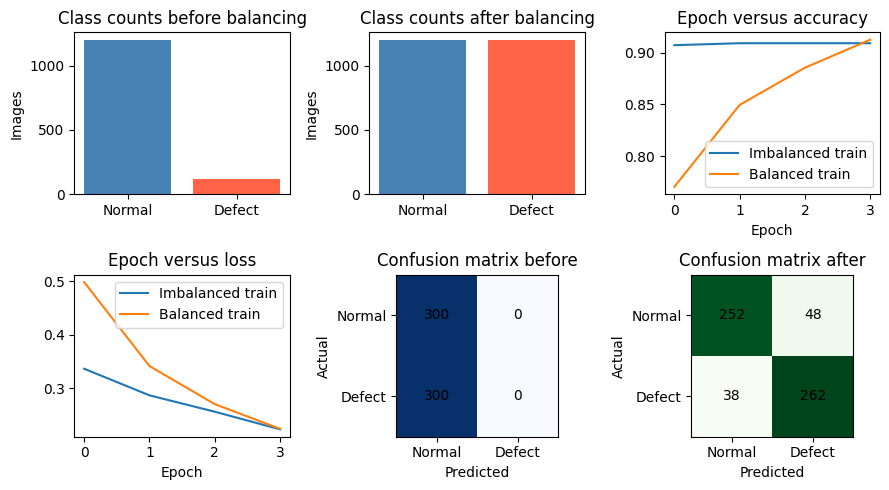

In [38]:
#@title Python Code - Defect Class Imbalance

# This script shows defect imbalance effects.
# We use a small CIFAR example.
# Metrics highlight safety critical defects.

# Install packages if needed.
# !pip install tensorflow scikit-learn pandas matplotlib

import os, warnings, random, math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
import tensorflow as tf

from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Show framework version briefly.
print('TensorFlow version:', tf.__version__)

# Detect available hardware safely.
gpu_list = tf.config.list_physical_devices('GPU')
use_gpu = len(gpu_list) > 0

print('Using GPU:', use_gpu)

# Load CIFAR ten dataset.
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.cifar10.load_data()
train_y = train_y.flatten()

test_y = test_y.flatten()

# Keep two classes only.
# Airplane means normal surface.
# Automobile means defect image substitute.

normal_id = 0
defect_id = 1

# Select binary subset indices.
train_mask = np.logical_or(train_y == normal_id, train_y == defect_id)
test_mask = np.logical_or(test_y == normal_id, test_y == defect_id)

train_x = train_x[train_mask]
train_y = train_y[train_mask]
test_x = test_x[test_mask]

test_y = test_y[test_mask]

# Convert labels to binary values.
train_y = (train_y == defect_id).astype('int32')
test_y = (test_y == defect_id).astype('int32')

# Normalize image values.
train_x = train_x.astype('float32') / 255.0
test_x = test_x.astype('float32') / 255.0

# Build an imbalanced training set.
normal_idx = np.where(train_y == 0)[0]
defect_idx = np.where(train_y == 1)[0]

normal_keep = normal_idx[:1200]
defect_keep = defect_idx[:120]
imbalanced_idx = np.concatenate([normal_keep, defect_keep])

# Shuffle selected training samples.
np.random.shuffle(imbalanced_idx)
train_x_imb = train_x[imbalanced_idx]

train_y_imb = train_y[imbalanced_idx]

# Create a balanced training set.
defect_repeat = math.ceil(len(normal_keep) / len(defect_keep))
extra_defect = np.tile(defect_keep, defect_repeat)

extra_defect = extra_defect[:len(normal_keep)]

balanced_idx = np.concatenate([normal_keep, extra_defect])
np.random.shuffle(balanced_idx)
train_x_bal = train_x[balanced_idx]

train_y_bal = train_y[balanced_idx]

# Build a small test subset.
test_normal = np.where(test_y == 0)[0][:300]
test_defect = np.where(test_y == 1)[0][:300]

test_idx = np.concatenate([test_normal, test_defect])
np.random.shuffle(test_idx)

test_x_small = test_x[test_idx]
test_y_small = test_y[test_idx]

# Check shapes before training.
assert train_x_imb.shape[0] > 0
assert train_x_bal.shape[0] > 0

assert test_x_small.shape[0] > 0

# Define a small CNN model.
def make_model():
    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Input(shape=(32, 32, 3)))
    model.add(tf.keras.layers.Conv2D(16, 3, activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D())

    model.add(tf.keras.layers.Conv2D(32, 3, activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D())
    model.add(tf.keras.layers.Flatten())

    model.add(tf.keras.layers.Dense(32, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    model.compile(

        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy'])

    return model

# Train on imbalanced data.
model_imb = make_model()
history_imb = model_imb.fit(

    train_x_imb,
    train_y_imb,
    epochs=4,

    batch_size=32,
    validation_split=0.2,
    verbose=0)

# Predict and score imbalanced model.
pred_imb = model_imb.predict(test_x_small, verbose=0)
pred_imb = (pred_imb.flatten() >= 0.5).astype('int32')

acc_imb = accuracy_score(test_y_small, pred_imb)
pre_imb = precision_score(test_y_small, pred_imb, zero_division=0)
rec_imb = recall_score(test_y_small, pred_imb, zero_division=0)

cm_imb = confusion_matrix(test_y_small, pred_imb)

# Train on balanced data.
model_bal = make_model()
history_bal = model_bal.fit(

    train_x_bal,
    train_y_bal,
    epochs=4,

    batch_size=32,
    validation_split=0.2,
    verbose=0)

# Predict and score balanced model.
pred_bal = model_bal.predict(test_x_small, verbose=0)
pred_bal = (pred_bal.flatten() >= 0.5).astype('int32')

acc_bal = accuracy_score(test_y_small, pred_bal)
pre_bal = precision_score(test_y_small, pred_bal, zero_division=0)
rec_bal = recall_score(test_y_small, pred_bal, zero_division=0)

cm_bal = confusion_matrix(test_y_small, pred_bal)

# Print short metric summary.
print('Imbalanced accuracy:', round(acc_imb, 3))
print('Imbalanced precision:', round(pre_imb, 3))

print('Imbalanced recall:', round(rec_imb, 3))
print('Balanced accuracy:', round(acc_bal, 3))
print('Balanced precision:', round(pre_bal, 3))

print('Balanced recall:', round(rec_bal, 3))

# Prepare values for one figure.
counts_before = [len(normal_keep), len(defect_keep)]
counts_after = [np.sum(train_y_bal == 0), np.sum(train_y_bal == 1)]

# Create one figure with six panels.
fig, axes = plt.subplots(2, 3, figsize=(9, 5))

# Plot class distributions.
axes[0, 0].bar(['Normal', 'Defect'], counts_before, color=['steelblue', 'tomato'])
axes[0, 0].set_title('Class counts before balancing')

axes[0, 0].set_ylabel('Images')

axes[0, 1].bar(['Normal', 'Defect'], counts_after, color=['steelblue', 'tomato'])
axes[0, 1].set_title('Class counts after balancing')
axes[0, 1].set_ylabel('Images')

# Plot training accuracy curves.
axes[0, 2].plot(history_imb.history['accuracy'], label='Imbalanced train')
axes[0, 2].plot(history_bal.history['accuracy'], label='Balanced train')

axes[0, 2].set_title('Epoch versus accuracy')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].legend()

# Plot training loss curves.
axes[1, 0].plot(history_imb.history['loss'], label='Imbalanced train')
axes[1, 0].plot(history_bal.history['loss'], label='Balanced train')

axes[1, 0].set_title('Epoch versus loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()

# Plot confusion matrix before balancing.
axes[1, 1].imshow(cm_imb, cmap='Blues')
axes[1, 1].set_title('Confusion matrix before')

axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_xticklabels(['Normal', 'Defect'])

axes[1, 1].set_yticklabels(['Normal', 'Defect'])
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

axes[1, 1].text(0, 0, str(cm_imb[0, 0]), ha='center', va='center')
axes[1, 1].text(1, 0, str(cm_imb[0, 1]), ha='center', va='center')
axes[1, 1].text(0, 1, str(cm_imb[1, 0]), ha='center', va='center')

axes[1, 1].text(1, 1, str(cm_imb[1, 1]), ha='center', va='center')

# Plot confusion matrix after balancing.
axes[1, 2].imshow(cm_bal, cmap='Greens')
axes[1, 2].set_title('Confusion matrix after')

axes[1, 2].set_xticks([0, 1])
axes[1, 2].set_yticks([0, 1])
axes[1, 2].set_xticklabels(['Normal', 'Defect'])

axes[1, 2].set_yticklabels(['Normal', 'Defect'])
axes[1, 2].set_xlabel('Predicted')
axes[1, 2].set_ylabel('Actual')

axes[1, 2].text(0, 0, str(cm_bal[0, 0]), ha='center', va='center')
axes[1, 2].text(1, 0, str(cm_bal[0, 1]), ha='center', va='center')
axes[1, 2].text(0, 1, str(cm_bal[1, 0]), ha='center', va='center')

axes[1, 2].text(1, 1, str(cm_bal[1, 1]), ha='center', va='center')

# Finish the figure neatly.
plt.tight_layout()
plt.show()

# <font color="#418FDE" size="6.5" uppercase>**Image Datasets and CNNs**</font>


In this lecture, you learned to:
- Organize a civil engineering image dataset into a labeled structure suitable for training and validation. 
- Implement transfer learning by fine-tuning a pre-trained convolutional neural network on a small civil engineering image dataset. 
- Evaluate an image classifier using metrics such as accuracy, precision, and recall with attention to safety-critical classes. 

In the next Lecture (Lecture B), we will go over 'Detection and Visualization'